# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

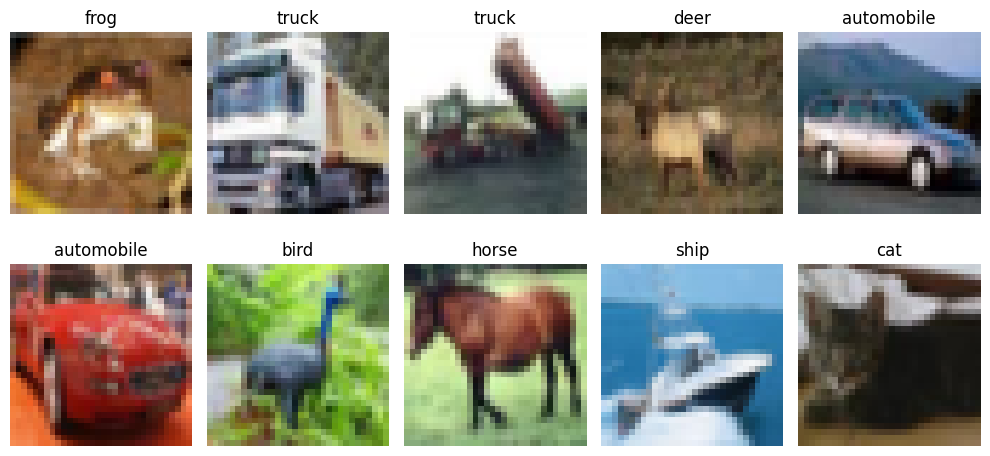

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.2712 - loss: 1.9894 - val_accuracy: 0.3206 - val_loss: 1.8791
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3135 - loss: 1.8684 - val_accuracy: 0.3650 - val_loss: 1.8018
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3389 - loss: 1.8098 - val_accuracy: 0.3908 - val_loss: 1.7218
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3493 - loss: 1.7811 - val_accuracy: 0.4062 - val_loss: 1.7075
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3622 - loss: 1.7532 - val_accuracy: 0.3916 - val_loss: 1.7106
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3696 - loss: 1.7303 - val_accuracy: 0.4100 - val_loss: 1.6785
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.3724 - loss: 1.7156 - val_accuracy: 0.3992 - val_loss: 1.6750
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3785 - loss: 1.7052 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4314 - loss: 1.6292
ANN Test Accuracy: 0.43140000104904175


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - accuracy: 0.4552 - loss: 1.5210 - val_accuracy: 0.5036 - val_loss: 1.4084
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.5952 - loss: 1.1516 - val_accuracy: 0.6064 - val_loss: 1.1076
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 63ms/step - accuracy: 0.6586 - loss: 0.9704 - val_accuracy: 0.6110 - val_loss: 1.1205
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.7046 - loss: 0.8480 - val_accuracy: 0.6506 - val_loss: 1.0408
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.7365 - loss: 0.7524 - val_accuracy: 0.6452 - val_loss: 1.0327
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7662 - loss: 0.6714 - val_accuracy: 0.7252 - val_loss: 0.8213
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 65ms/step - accuracy: 0.7863 - loss: 0.6094 - val_accuracy: 0.7288 - val_loss: 0.8379
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.8071 - loss: 0.5438 - 

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7071 - loss: 0.9440
CNN Test Accuracy: 0.707099974155426


## 📈 Compare Learning Curves

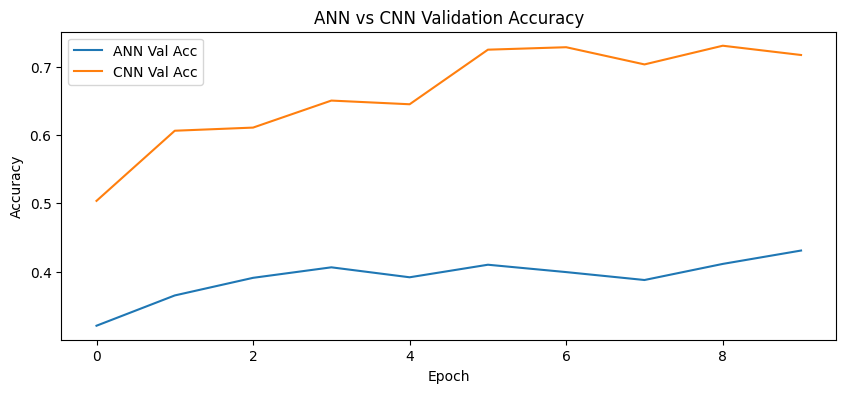

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4314
1,CNN,0.7071


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

advanced_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

advanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

advanced_history = advanced_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 142ms/step - accuracy: 0.3680 - loss: 1.7875 - val_accuracy: 0.4346 - val_loss: 1.5800
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 138ms/step - accuracy: 0.4821 - loss: 1.4546 - val_accuracy: 0.5380 - val_loss: 1.2569
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 137ms/step - accuracy: 0.5320 - loss: 1.3130 - val_accuracy: 0.5180 - val_loss: 1.4053
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 134ms/step - accuracy: 0.5695 - loss: 1.2333 - val_accuracy: 0.5748 - val_loss: 1.2401
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 135ms/step - accuracy: 0.5947 - loss: 1.1580 - val_accuracy: 0.6652 - val_loss: 0.9616
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 130ms/step - accuracy: 0.6179 - loss: 1.1000 - val_accuracy: 0.5734 - val_loss: 1.2195
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.6343 - loss: 1.0604 - val_accuracy: 0.6008 - val_loss: 1.1680
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 129ms/step - accuracy: 0.6482 - l

In [14]:
advanced_loss, advanced_acc = advanced_model.evaluate(x_test_norm, y_test)

print("Advanced CNN Accuracy:", advanced_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6609 - loss: 0.9805
Advanced CNN Accuracy: 0.6608999967575073


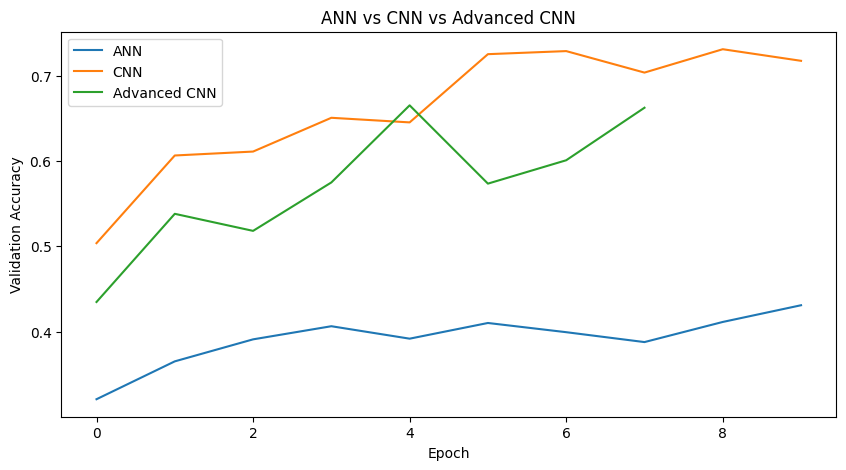

In [15]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(advanced_history.history['val_accuracy'], label='Advanced CNN')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN vs Advanced CNN")

plt.legend()
plt.show()

In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Advanced CNN"],
    "Test Accuracy": [
        ann_model.evaluate(x_test_flat, y_test, verbose=0)[1],
        cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1],
        advanced_model.evaluate(x_test_norm, y_test, verbose=0)[1]
    ]
})

print(comparison)

          Model  Test Accuracy
0           ANN         0.4314
1           CNN         0.7071
2  Advanced CNN         0.6609


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**